# STEP 4: VAR Modeling for `cpi_mom`

Notebook này áp dụng mô hình **VAR** cho trường hợp biến mục tiêu `cpi_mom` là chuỗi dừng I(0).

## Mục tiêu

1. Chuẩn bị dữ liệu cho VAR.
2. Kiểm định tính dừng bằng ADF/KPSS.
3. Giữ `cpi_mom` ở dạng level vì đã là I(0).
4. Biến đổi các biến không dừng về dạng dừng bằng `log_diff` hoặc `diff`.
5. Lựa chọn biến cho VAR dựa trên lag correlation và ý nghĩa kinh tế.
6. Chọn độ trễ tối ưu bằng AIC/BIC/HQIC.
7. Huấn luyện VAR và dự báo `cpi_mom`.
8. So sánh với benchmark Random Walk và Mean Forecast.
9. Kiểm định diagnostics: stability, Ljung-Box, Jarque-Bera, Granger causality.

## Lưu ý quan trọng

- VAR yêu cầu các biến trong mô hình là dừng.
- Không đưa trực tiếp level của biến I(1) vào VAR.
- Nếu biến dương và không dừng, dùng `log_diff`.
- Nếu biến không phù hợp log, dùng `diff`.

## 1. Setup and Configuration

In [60]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

SCRIPT_DIR = os.getcwd()
DATA_DIR = os.path.join(SCRIPT_DIR, 'data', 'processed')

print(f"Data Directory: {DATA_DIR}")

Data Directory: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed


## 2. Load Data

In [61]:
cleaned_data = pd.read_csv(os.path.join(DATA_DIR, 'cpi_02_06_selected_variables.csv'))
cleaned_data['date'] = pd.to_datetime(cleaned_data['date'])
cleaned_data = cleaned_data.sort_values('date').reset_index(drop=True)

print(f"Loaded cleaned data: {cleaned_data.shape[0]} months × {cleaned_data.shape[1]} columns")
print(f"Date range: {cleaned_data['date'].min().date()} to {cleaned_data['date'].max().date()}")
print(f"Missing values: {cleaned_data.isnull().sum().sum()}")
print(cleaned_data.head().to_string(index=False))

Loaded cleaned data: 360 months × 13 columns
Date range: 1995-01-01 to 2024-12-01
Missing values: 0
      date  cpi_mom  policy_rate  broad_money  ppi_qoq   wti  gasoline_world       gold  policy_rate.1  VNINDEX    NIKKEI225  USDVND      gdp
1995-01-01    103.8         10.8        3.567    -0.73 18.39           0.822 278.299988           10.8   101.55 18649.820312 11039.0 434478.0
1995-02-01    103.4         10.8        3.303    -0.73 18.49           0.822 278.299988           10.8   101.55 17053.429688 11050.0 434478.0
1995-03-01    100.2         10.8        3.495    -0.73 19.17           0.822 278.299988           10.8   101.55 16139.950195 11045.0 434478.0
1995-04-01    101.0         10.8        3.434    -0.73 20.38           0.822 278.299988           10.8   101.55 16806.750000 11041.0 434478.0
1995-05-01    101.8         10.8        3.247    -0.73 18.89           0.822 278.299988           10.8   101.55 15436.790039 11045.0 434478.0


## 3. VAR Model Setup

In [62]:
df = cleaned_data.copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_var = 'cpi_mom'

if target_var not in df.columns:
    raise ValueError(f"{target_var} not found in cleaned_data columns")

candidate_vars = [
    'cpi_mom', 'broad_money', 'ppi_qoq', 'wti', 'gold', 'policy_rate', 'VNINDEX', 'NIKKEI225', 'USDVND', 'gdp'
]

candidate_vars = [v for v in candidate_vars if v in df.columns]

print("=" * 100)
print("VAR MODEL SETUP")
print("=" * 100)
print(f"Target variable: {target_var}")
print(f"Data shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print("Candidate variables found:")
print(candidate_vars)

VAR MODEL SETUP
Target variable: cpi_mom
Data shape: (360, 13)
Date range: 1995-01-01 to 2024-12-01
Candidate variables found:
['cpi_mom', 'broad_money', 'ppi_qoq', 'wti', 'gold', 'policy_rate', 'VNINDEX', 'NIKKEI225', 'USDVND', 'gdp']


## 4. Stationarity Test Helpers

In [63]:
def adf_test(series):
    series = pd.Series(series).dropna()
    try:
        return adfuller(series, autolag='AIC')[1]
    except Exception:
        return np.nan


def kpss_test(series):
    series = pd.Series(series).dropna()
    try:
        return kpss(series, regression='c', nlags='auto')[1]
    except Exception:
        return np.nan


def classify_stationarity(series):
    """
    ADF H0: non-stationary.
    KPSS H0: stationary.
    """
    adf_p = adf_test(series)
    kpss_p = kpss_test(series)

    adf_stationary = adf_p < 0.05 if pd.notna(adf_p) else False
    kpss_stationary = kpss_p > 0.05 if pd.notna(kpss_p) else False

    if adf_stationary and kpss_stationary:
        status = "I(0)"
    elif not adf_stationary:
        status = "Non-stationary"
    else:
        status = "Mixed/unclear"

    return adf_p, kpss_p, status

## 5. Transform Variables to Stationary Form for VAR

In [64]:
df_var = df[['date']].copy()
transform_records = []

for var in candidate_vars:
    series = df[var].copy()
    adf_p, kpss_p, status = classify_stationarity(series)

    if var == target_var:
        new_name = var
        df_var[new_name] = series
        method = 'level_target_I0'
        adf_after, kpss_after = adf_p, kpss_p
    else:
        if status == "I(0)":
            new_name = var
            df_var[new_name] = series
            method = 'level_I0'
            adf_after, kpss_after = adf_p, kpss_p
        else:
            if (series > 0).all():
                new_name = f'dlog_{var}'
                df_var[new_name] = np.log(series).diff()
                method = 'log_diff'
            else:
                new_name = f'diff_{var}'
                df_var[new_name] = series.diff()
                method = 'diff'
            adf_after = adf_test(df_var[new_name])
            kpss_after = kpss_test(df_var[new_name])

    transform_records.append({
        'Original': var,
        'Transformed': new_name,
        'Method': method,
        'ADF_p_before': adf_p,
        'KPSS_p_before': kpss_p,
        'Status_before': status,
        'ADF_p_after': adf_after,
        'KPSS_p_after': kpss_after
    })

transform_df = pd.DataFrame(transform_records)

print("=" * 100)
print("TRANSFORMATION SUMMARY")
print("=" * 100)
print(transform_df.to_string(index=False))

df_var = df_var.dropna().reset_index(drop=True)

print("VAR-ready data shape:", df_var.shape)
print("Columns:")
print(df_var.columns.tolist())

TRANSFORMATION SUMMARY
   Original      Transformed          Method  ADF_p_before  KPSS_p_before  Status_before  ADF_p_after  KPSS_p_after
    cpi_mom          cpi_mom level_target_I0      0.003148           0.10           I(0) 3.147732e-03           0.1
broad_money dlog_broad_money        log_diff      0.280602           0.01 Non-stationary 2.078913e-04           0.1
    ppi_qoq     diff_ppi_qoq            diff      0.307828           0.01 Non-stationary 1.350403e-14           0.1
        wti         dlog_wti        log_diff      0.121689           0.01 Non-stationary 1.462145e-18           0.1
       gold        dlog_gold        log_diff      0.989363           0.01 Non-stationary 0.000000e+00           0.1
policy_rate dlog_policy_rate        log_diff      0.121117           0.01 Non-stationary 1.100161e-12           0.1
    VNINDEX     dlog_VNINDEX        log_diff      0.721155           0.01 Non-stationary 2.676718e-12           0.1
  NIKKEI225   dlog_NIKKEI225        log_diff     

In [65]:
# kiểm định lại stationarity sau khi biến đổi
stationarity_results = []
for col in df_var.columns:
    if col != 'date':
        adf_p = adf_test(df_var[col])
        kpss_p = kpss_test(df_var[col])
        stationarity_results.append({
            'Variable': col,
            'ADF_p': adf_p,
            'KPSS_p': kpss_p,
            'Stationary': (adf_p < 0.05) and (kpss_p > 0.05)
        })
stationarity_df = pd.DataFrame(stationarity_results)

print(stationarity_df.to_string(index=False))

        Variable        ADF_p  KPSS_p  Stationary
         cpi_mom 1.392488e-03     0.1        True
dlog_broad_money 2.078913e-04     0.1        True
    diff_ppi_qoq 1.350403e-14     0.1        True
        dlog_wti 1.462145e-18     0.1        True
       dlog_gold 0.000000e+00     0.1        True
dlog_policy_rate 1.100161e-12     0.1        True
    dlog_VNINDEX 2.676718e-12     0.1        True
  dlog_NIKKEI225 5.167798e-30     0.1        True
     dlog_USDVND 1.861147e-03     0.1        True
        dlog_gdp 1.411166e-12     0.1        True


## 6. Variable Selection by Lag Correlation

In [66]:
def max_abs_lag_corr(df_input, target, feature, max_lag=12):
    """Corr target_t with feature_{t-lag}."""
    best_lag = None
    best_corr = np.nan

    for lag in range(0, max_lag + 1):
        if lag == 0:
            corr = df_input[target].corr(df_input[feature])
        else:
            corr = df_input[target].corr(df_input[feature].shift(lag))

        if pd.notna(corr):
            if pd.isna(best_corr) or abs(corr) > abs(best_corr):
                best_corr = corr
                best_lag = lag

    return best_corr, best_lag


all_var_ready_cols = [c for c in df_var.columns if c != 'date']

if target_var not in all_var_ready_cols:
    raise ValueError(f"{target_var} not found in VAR-ready data")

feature_cols = [c for c in all_var_ready_cols if c != target_var]
selection_records = []

for col in feature_cols:
    corr_0 = df_var[target_var].corr(df_var[col])
    max_corr, best_lag = max_abs_lag_corr(df_var, target_var, col, max_lag=12)

    selection_records.append({
        'Feature': col,
        'Corr_lag0': corr_0,
        'Max_abs_lag_corr': max_corr,
        'Best_lag': best_lag
    })

selection_df = pd.DataFrame(selection_records)
selection_df['abs_Max_corr'] = selection_df['Max_abs_lag_corr'].abs()
selection_df = selection_df.sort_values('abs_Max_corr', ascending=False)

print("=" * 100)
print("LAG CORRELATION VARIABLE SELECTION")
print("=" * 100)
print(selection_df.to_string(index=False))

LAG CORRELATION VARIABLE SELECTION
         Feature  Corr_lag0  Max_abs_lag_corr  Best_lag  abs_Max_corr
dlog_policy_rate   0.348265          0.348265         0      0.348265
        dlog_wti   0.144126          0.202173         1      0.202173
  dlog_NIKKEI225  -0.030906         -0.199650         4      0.199650
        dlog_gdp  -0.081433          0.169718        10      0.169718
       dlog_gold   0.047122          0.154209         5      0.154209
dlog_broad_money  -0.127655          0.151517         2      0.151517
    dlog_VNINDEX  -0.079749         -0.125599         4      0.125599
     dlog_USDVND   0.068702          0.115845        11      0.115845
    diff_ppi_qoq   0.026497          0.075418         7      0.075418


## 8. Fit and Evaluate VAR Models

In [ ]:
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

target_var = 'cpi_mom'

candidate_vars = [
    'cpi_mom', 'dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti',
    'dlog_gold', 'dlog_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND', 'dlog_gdp'
]

var_configurations = [
    {'name': 'VAR_All_Candidates', 'vars': candidate_vars}
]

def evaluate_var_model(df, vars_list, target=target_var, test_ratio=0.2, maxlags=6):
    data = df[vars_list].dropna()

    split = int(len(data) * (1 - test_ratio))
    train, test = data.iloc[:split], data.iloc[split:]

    try:
        model = VAR(train)
        lag = model.select_order(maxlags).selected_orders['aic'] 

        fitted = model.fit(lag)

        fc = fitted.forecast(train.values[-lag:], steps=len(test))
        fc = pd.DataFrame(fc, index=test.index, columns=vars_list)

        y_true = test[target]
        y_pred = fc[target]

        return {
            'status': 'success',
            'Lag': lag,
            'RMSE': sqrt(round(mean_squared_error(y_true, y_pred,), 6)),
            'MAE': round(mean_absolute_error(y_true, y_pred), 6),
            'R2': round(r2_score(y_true, y_pred), 6),
            'Stable': fitted.is_stable(verbose=False)
        }

    except Exception as e:
        return {'status': 'failed', 'error': str(e)}



In [68]:
var_results = []

for cfg in var_configurations:
    out = evaluate_var_model(df=df_var, vars_list=cfg['vars'])

    if out['status'] == 'success':
        out['Model'] = cfg['name']
        del out['status']
        var_results.append(out)

        print(
            f"{cfg['name']} -> "
            f"Lag: {out['Lag']} | "
            f"RMSE: {out['RMSE']} | "
            f"MAE: {out['MAE']} | "
            f"R2: {out['R2']} | "
            f"Stable: {out['Stable']}"
        )
    else:
        print(f"{cfg['name']} -> Failed: {out['error']}")

if var_results:
    result_df = pd.DataFrame(var_results).sort_values('RMSE')
    print(result_df)

VAR_All_Candidates -> Lag: 6 | RMSE: 0.5532341276530218 | MAE: 0.43491 | R2: -0.388647 | Stable: True
   Lag      RMSE      MAE        R2  Stable               Model
0    6  0.553234  0.43491 -0.388647    True  VAR_All_Candidates


## 10. Actual vs Forecast Plot

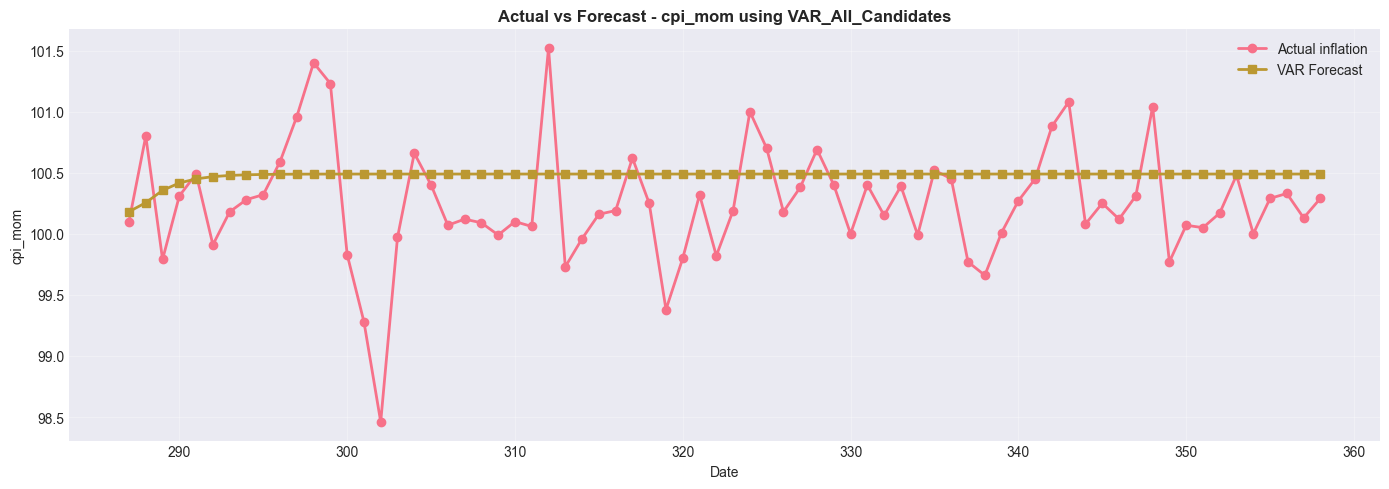

In [69]:
best_model_name = result_df.iloc[0]['Model']
best_vars = next(cfg['vars'] for cfg in var_configurations if cfg['name'] == best_model_name)

data = df_var[best_vars].dropna()
split = int(len(data) * 0.8)
train, test = data.iloc[:split], data.iloc[split:]

model = VAR(train)
lag = model.select_order(6).selected_orders['bic'] or 1
fit = model.fit(lag)

forecast = fit.forecast(train.values[-lag:], steps=len(test))
forecast = pd.DataFrame(forecast, index=test.index, columns=best_vars)

plt.figure(figsize=(14, 5))
plt.plot(test.index, test[target_var], marker='o', lw=2, label='Actual inflation')
plt.plot(forecast.index, forecast[target_var], marker='s', lw=2, label='VAR Forecast')

plt.title(f'Actual vs Forecast - {target_var} using {best_model_name}', fontweight='bold')
plt.xlabel('Date')
plt.ylabel(target_var)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Rolling One-Step-Ahead Forecast

In [70]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def rolling_var_forecast(df, vars_list, target, lag=1, initial_train_ratio=0.8):
    data = df[['date'] + vars_list].dropna().set_index('date')
    start = int(len(data) * initial_train_ratio)

    preds, actuals, dates = [], [], []

    for t in range(start, len(data)):
        train = data.iloc[:t]
        actual = data.iloc[t][target]

        try:
            fit = VAR(train).fit(lag)
            pred = fit.forecast(train.values[-lag:], steps=1)[0]
            preds.append(pred[vars_list.index(target)])
            actuals.append(actual)
            dates.append(data.index[t])
        except Exception:
            continue

    y_true = np.array(actuals)
    y_pred = np.array(preds)

    return pd.DataFrame({
        'date': dates,
        'actual': y_true,
        'forecast': y_pred
    }).assign(
        RMSE=np.sqrt(mean_squared_error(y_true, y_pred)),
        MAE=mean_absolute_error(y_true, y_pred),
        R2=r2_score(y_true, y_pred)
    )

In [71]:
best_model_name = result_df.iloc[0]['Model']
best_vars = next(cfg['vars'] for cfg in var_configurations if cfg['name'] == best_model_name)
best_lag = int(result_df.iloc[0]['Lag'])

rolling_df = rolling_var_forecast(
    df=df_var,
    vars_list=best_vars,
    target=target_var,
    lag=best_lag,
    initial_train_ratio=0.8
)

print("=" * 80)
print("ROLLING ONE-STEP-AHEAD FORECAST")
print("=" * 80)
print(f"Model: {best_model_name}")
print(f"Lag  : {best_lag}")
print(f"RMSE : {rolling_df['RMSE'].iloc[0]:.6f}")
print(f"MAE  : {rolling_df['MAE'].iloc[0]:.6f}")
print(f"R2   : {rolling_df['R2'].iloc[0]:.4f}")

ROLLING ONE-STEP-AHEAD FORECAST
Model: VAR_All_Candidates
Lag  : 6
RMSE : 0.515854
MAE  : 0.388227
R2   : -0.2073


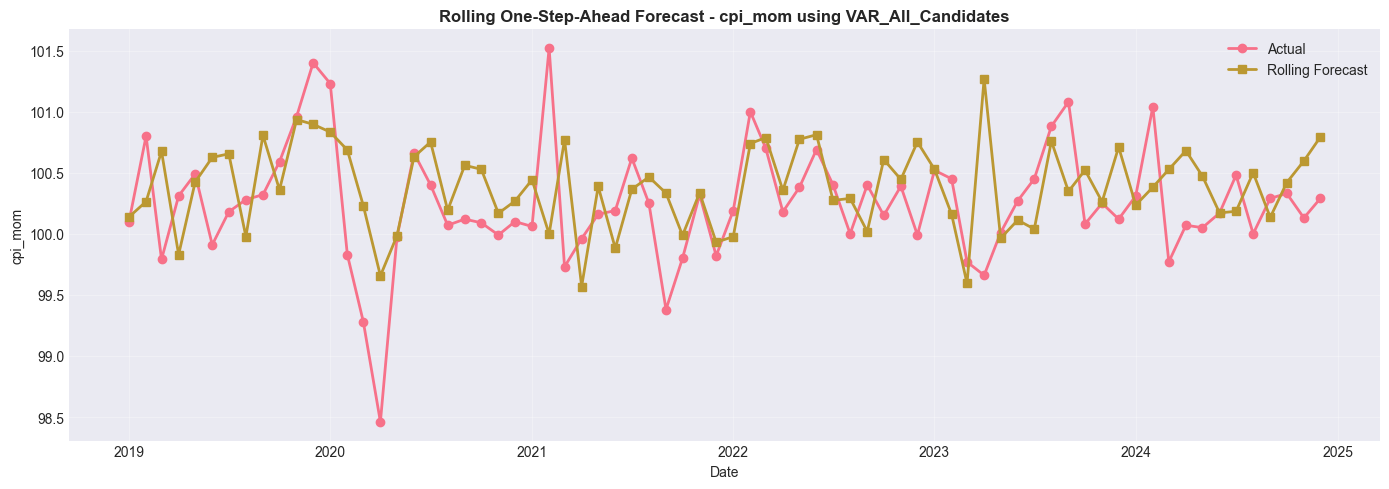

In [72]:
plt.figure(figsize=(14, 5))

plt.plot(rolling_df['date'], rolling_df['actual'], marker='o', lw=2, label='Actual')
plt.plot(rolling_df['date'], rolling_df['forecast'], marker='s', lw=2, label='Rolling Forecast')

plt.title(f'Rolling One-Step-Ahead Forecast - {target_var} using {best_model_name}', fontweight='bold')
plt.xlabel('Date')
plt.ylabel(target_var)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Residual Diagnostics for Target Equation

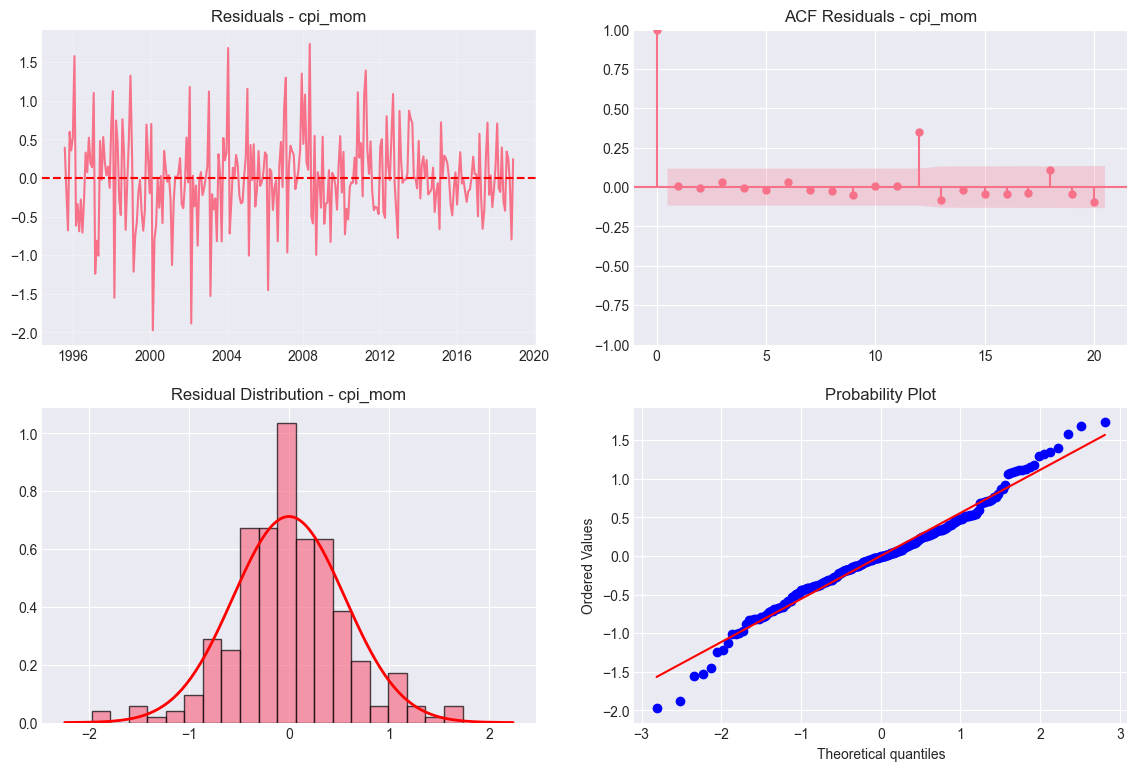

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

if not result_df.empty:
    best_model_name = result_df.iloc[0]['Model']
    best_vars = next(c['vars'] for c in var_configurations if c['name'] == best_model_name)
    best_lag = int(result_df.iloc[0]['Lag'])

    data = df_var[['date'] + best_vars].dropna().set_index('date')
    split = int(len(data) * 0.8)
    train = data.iloc[:split]

    best_var_model = VAR(train).fit(best_lag)
    resid = best_var_model.resid[target_var].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].plot(resid.index, resid)
    axes[0, 0].axhline(0, color='red', ls='--')
    axes[0, 0].set_title(f'Residuals - {target_var}')
    axes[0, 0].grid(alpha=0.3)

    plot_acf(resid, lags=min(20, len(resid)//2), ax=axes[0, 1])
    axes[0, 1].set_title(f'ACF Residuals - {target_var}')

    axes[1, 0].hist(resid, bins=20, density=True, alpha=0.7, edgecolor='black')
    mu, sigma = resid.mean(), resid.std()

    if sigma > 0:
        x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
        axes[1, 0].plot(x, stats.norm.pdf(x, mu, sigma), color='red', lw=2)

    axes[1, 0].set_title(f'Residual Distribution - {target_var}')
    stats.probplot(resid.dropna().values, dist='norm', plot=axes[1, 1])



Data Directory: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed
Loaded cleaned data: 360 months × 13 columns
Date range: 1995-01-01 to 2024-12-01
Missing values: 0
      date  cpi_mom  policy_rate  broad_money  ppi_qoq   wti  gasoline_world       gold  policy_rate.1  VNINDEX    NIKKEI225  USDVND      gdp
1995-01-01    103.8         10.8        3.567    -0.73 18.39           0.822 278.299988           10.8   101.55 18649.820312 11039.0 434478.0
1995-02-01    103.4         10.8        3.303    -0.73 18.49           0.822 278.299988           10.8   101.55 17053.429688 11050.0 434478.0
1995-03-01    100.2         10.8        3.495    -0.73 19.17           0.822 278.299988           10.8   101.55 16139.950195 11045.0 434478.0
1995-04-01    101.0         10.8        3.434    -0.73 20.38           0.822 278.299988           10.8   101.55 16806.750000 11041.0 434478.0
1995-05-01    101.8         10.8        3.247    -0.73 18.89           0.822 278.299988           10.8  

C:\Users\HP\AppData\Local\Temp\ipykernel_27472\3047160005.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(series, regression='c', nlags='auto')[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_27472\3047160005.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(series, regression='c', nlags='auto')[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_27472\3047160005.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(series, regression='c', nlags='auto')[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_27472\3047160005.py:62: InterpolationWarning: The test statistic is outside of the range of p-valu

VAR-ready data shape: (359, 11)
Columns:
['date', 'cpi_mom', 'dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'dlog_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND', 'dlog_gdp']
        Variable        ADF_p  KPSS_p  Stationary
         cpi_mom 1.392488e-03     0.1        True
dlog_broad_money 2.078913e-04     0.1        True
    diff_ppi_qoq 1.350403e-14     0.1        True
        dlog_wti 1.462145e-18     0.1        True
       dlog_gold 0.000000e+00     0.1        True
dlog_policy_rate 1.100161e-12     0.1        True
    dlog_VNINDEX 2.676718e-12     0.1        True
  dlog_NIKKEI225 5.167798e-30     0.1        True
     dlog_USDVND 1.861147e-03     0.1        True
        dlog_gdp 1.411166e-12     0.1        True
Standardized VAR data shape (Target excluded from scaler): (359, 11)
Columns:
['date', 'cpi_mom', 'dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'dlog_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND', 'dlog_gdp']
LAG COR

C:\Users\HP\AppData\Local\Temp\ipykernel_27472\3047160005.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(series, regression='c', nlags='auto')[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_27472\3047160005.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(series, regression='c', nlags='auto')[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_27472\3047160005.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(series, regression='c', nlags='auto')[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_27472\3047160005.py:62: InterpolationWarning: The test statistic is outside of the range of p-valu

Does dlog_gold Granger-cause cpi_mom? Min p-value across lags 1-6: 0.0123
Does dlog_policy_rate Granger-cause cpi_mom? Min p-value across lags 1-6: 0.0216
Does dlog_VNINDEX Granger-cause cpi_mom? Min p-value across lags 1-6: 0.1892
Does dlog_NIKKEI225 Granger-cause cpi_mom? Min p-value across lags 1-6: 0.0000
Does dlog_USDVND Granger-cause cpi_mom? Min p-value across lags 1-6: 0.0427
Does dlog_gdp Granger-cause cpi_mom? Min p-value across lags 1-6: 0.0056
VAR_Granger_Optimal (Standard) -> Lag: 2 | RMSE: 0.528456242275555 | MAE: 0.414765 | R2: -0.267047 | Stable: True
VAR_All_Candidates (Standard) -> Lag: 1 | RMSE: 0.5242098816313939 | MAE: 0.410668 | R2: -0.246765 | Stable: True
   Lag      RMSE       MAE        R2  Stable                Model
1    1  0.524210  0.410668 -0.246765    True   VAR_All_Candidates
0    2  0.528456  0.414765 -0.267047    True  VAR_Granger_Optimal


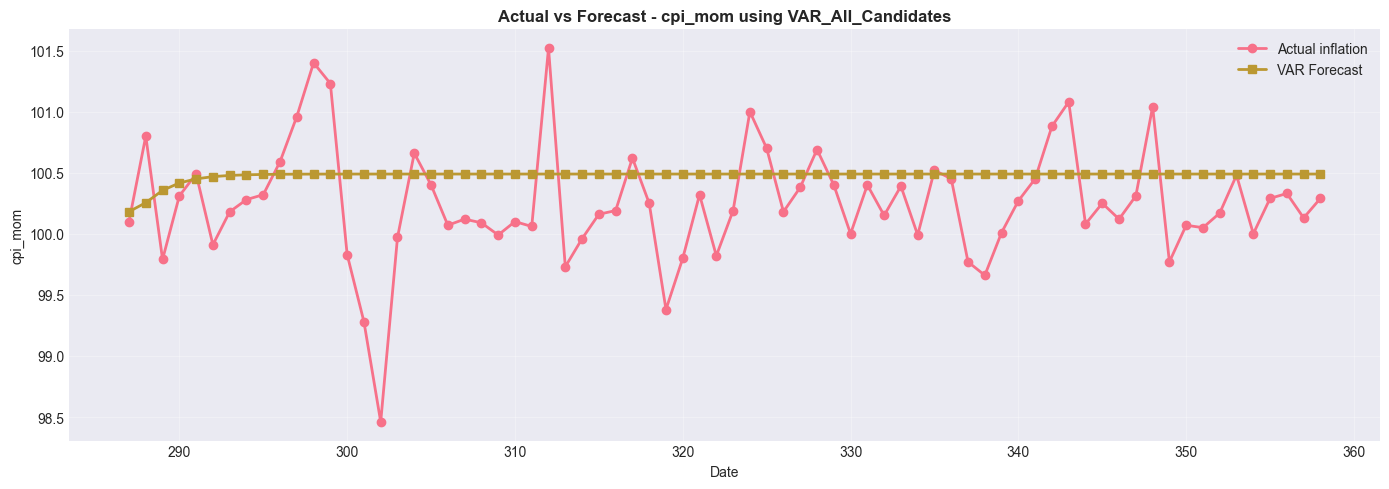

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-package

ROLLING ONE-STEP-AHEAD FORECAST
Model: VAR_All_Candidates
Lag  : 1
RMSE : 0.459099
MAE  : 0.344142
R2   : 0.0437


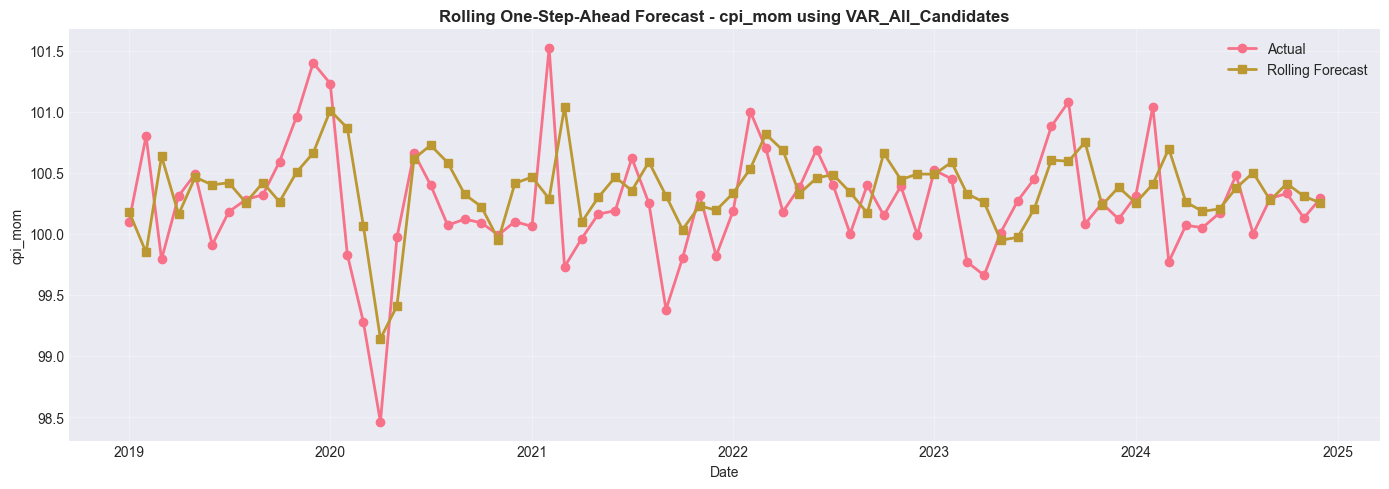

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


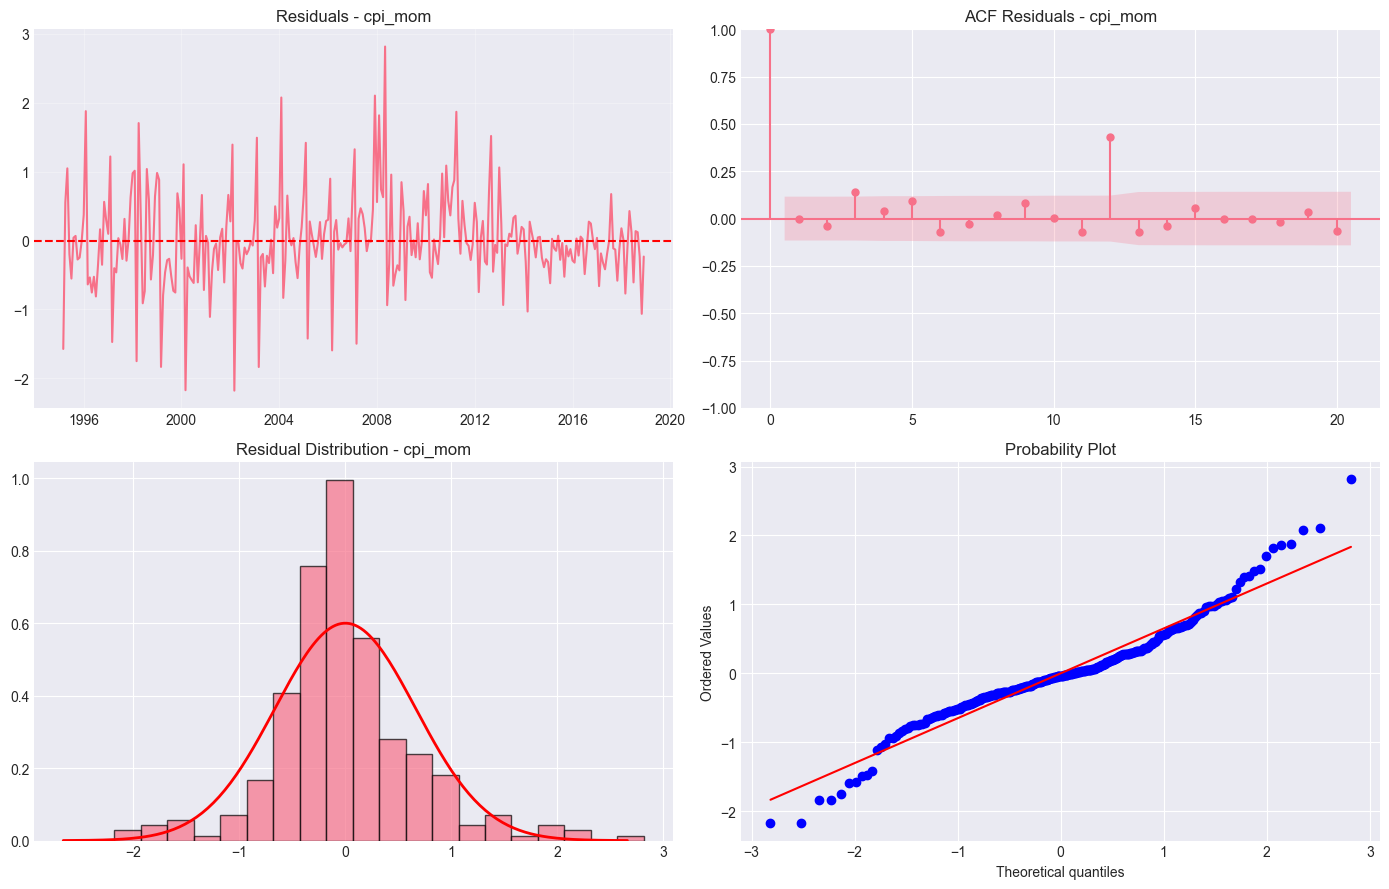

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from math import sqrt

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

SCRIPT_DIR = os.getcwd()
DATA_DIR = os.path.join(SCRIPT_DIR, 'data', 'processed')
print(f"Data Directory: {DATA_DIR}")

cleaned_data = pd.read_csv(os.path.join(DATA_DIR, 'cpi_02_06_selected_variables.csv'))
cleaned_data['date'] = pd.to_datetime(cleaned_data['date'])
cleaned_data = cleaned_data.sort_values('date').reset_index(drop=True)
print(f"Loaded cleaned data: {cleaned_data.shape[0]} months × {cleaned_data.shape[1]} columns")
print(f"Date range: {cleaned_data['date'].min().date()} to {cleaned_data['date'].max().date()}")
print(f"Missing values: {cleaned_data.isnull().sum().sum()}")
print(cleaned_data.head().to_string(index=False))

df = cleaned_data.copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
target_var = 'cpi_mom'
if target_var not in df.columns:
    raise ValueError(f"{target_var} not found in cleaned_data columns")
candidate_vars = [
    'cpi_mom', 'broad_money', 'ppi_qoq', 'wti', 'gold', 'policy_rate', 'VNINDEX', 'NIKKEI225', 'USDVND', 'gdp']
candidate_vars = [v for v in candidate_vars if v in df.columns]
print("=" * 100)
print("VAR MODEL SETUP")
print("=" * 100)
print(f"Target variable: {target_var}")
print(f"Data shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print("Candidate variables found:")
print(candidate_vars)

def adf_test(series):
    series = pd.Series(series).dropna()
    try:
        return adfuller(series, autolag='AIC')[1]
    except Exception:
        return np.nan

def kpss_test(series):
    series = pd.Series(series).dropna()
    try:
        return kpss(series, regression='c', nlags='auto')[1]
    except Exception:
        return np.nan

def classify_stationarity(series):
    adf_p = adf_test(series)
    kpss_p = kpss_test(series)

    adf_stationary = adf_p < 0.05 if pd.notna(adf_p) else False
    kpss_stationary = kpss_p > 0.05 if pd.notna(kpss_p) else False

    if adf_stationary and kpss_stationary:
        status = "I(0)"
    elif not adf_stationary:
        status = "Non-stationary"
    else:
        status = "Mixed/unclear"

    return adf_p, kpss_p, status

df_var = df[['date']].copy()
transform_records = []
for var in candidate_vars:
    series = df[var].copy()
    adf_p, kpss_p, status = classify_stationarity(series)

    if var == target_var:
        new_name = var
        df_var[new_name] = series
        method = 'level_target_I0'
        adf_after, kpss_after = adf_p, kpss_p
    else:
        if status == "I(0)":
            new_name = var
            df_var[new_name] = series
            method = 'level_I0'
            adf_after, kpss_after = adf_p, kpss_p
        else:
            if (series > 0).all():
                new_name = f'dlog_{var}'
                df_var[new_name] = np.log(series).diff()
                method = 'log_diff'
            else:
                new_name = f'diff_{var}'
                df_var[new_name] = series.diff()
                method = 'diff'
            adf_after = adf_test(df_var[new_name])
            kpss_after = kpss_test(df_var[new_name])

    transform_records.append({
        'Original': var,
        'Transformed': new_name,
        'Method': method,
        'ADF_p_before': adf_p,
        'KPSS_p_before': kpss_p,
        'Status_before': status,
        'ADF_p_after': adf_after,
        'KPSS_p_after': kpss_after
    })
transform_df = pd.DataFrame(transform_records)
print("=" * 100)
print("TRANSFORMATION SUMMARY")
print("=" * 100)
print(transform_df.to_string(index=False))
df_var = df_var.dropna().reset_index(drop=True)
print("VAR-ready data shape:", df_var.shape)
print("Columns:")
print(df_var.columns.tolist())

stationarity_results = []
for col in df_var.columns:
    if col != 'date':
        adf_p = adf_test(df_var[col])
        kpss_p = kpss_test(df_var[col])
        stationarity_results.append({
            'Variable': col,
            'ADF_p': adf_p,
            'KPSS_p': kpss_p,
            'Stationary': (adf_p < 0.05) and (kpss_p > 0.05)
        })
stationarity_df = pd.DataFrame(stationarity_results)
print(stationarity_df.to_string(index=False))

scaler = StandardScaler()
exog_columns = [col for col in df_var.columns if col != 'date' and col != target_var]
df_var[exog_columns] = scaler.fit_transform(df_var[exog_columns])
print("Standardized VAR data shape (Target excluded from scaler):", df_var.shape)
print("Columns:")
print(df_var.columns.tolist())

def max_abs_lag_corr(df_input, target, feature, max_lag=24):
    best_lag = None
    best_corr = np.nan

    for lag in range(0, max_lag + 1):
        if lag == 0:
            corr = df_input[target].corr(df_input[feature])
        else:
            corr = df_input[target].corr(df_input[feature].shift(lag))

        if pd.notna(corr):
            if pd.isna(best_corr) or abs(corr) > abs(best_corr):
                best_corr = corr
                best_lag = lag

    return best_corr, best_lag

all_var_ready_cols = [c for c in df_var.columns if c != 'date']
if target_var not in all_var_ready_cols:
    raise ValueError(f"{target_var} not found in VAR-ready data")
feature_cols = [c for c in all_var_ready_cols if c != target_var]
selection_records = []
for col in feature_cols:
    corr_0 = df_var[target_var].corr(df_var[col])
    max_corr, best_lag = max_abs_lag_corr(df_var, target_var, col, max_lag=24)

    selection_records.append({
        'Feature': col,
        'Corr_lag0': corr_0,
        'Max_abs_lag_corr': max_corr,
        'Best_lag': best_lag
    })
selection_df = pd.DataFrame(selection_records)
selection_df['abs_Max_corr'] = selection_df['Max_abs_lag_corr'].abs()
selection_df = selection_df.sort_values('abs_Max_corr', ascending=False)
print("=" * 100)
print("LAG CORRELATION VARIABLE SELECTION")
print("=" * 100)
print(selection_df.to_string(index=False))

print("=" * 100)
print("GRANGER CAUSALITY TEST (Max Lag = 4)")
print("=" * 100)
for col in feature_cols:
    try:
        g_res = grangercausalitytests(df_var[[target_var, col]], maxlag=6, verbose=False)
        p_values = [g_res[i][0]['ssr_ftest'][1] for i in range(1, 7)]
        min_p = min(p_values)
        print(f"Does {col} Granger-cause {target_var}? Min p-value across lags 1-6: {min_p:.4f}")
    except Exception:
        continue

target_var = 'cpi_mom'
candidate_vars_all = [
    'cpi_mom', 'dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti',
    'dlog_gold', 'dlog_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND', 'dlog_gdp']

candidate_vars_granger = [
    'cpi_mom', 'dlog_broad_money', 'dlog_wti', 'dlog_policy_rate', 'dlog_gdp', 'dlog_USDVND']

var_configurations = [
    {'name': 'VAR_Granger_Optimal', 'vars': candidate_vars_granger},
    {'name': 'VAR_All_Candidates', 'vars': candidate_vars_all}
]

def evaluate_var_model(df, vars_list, target=target_var, test_ratio=0.20, maxlags=2):
    data = df[vars_list].dropna()
    
    split = int(len(data) * (1 - test_ratio))
    train, test = data.iloc[:split], data.iloc[split:]

    try:
        model = VAR(train)
        lag = model.select_order(maxlags).selected_orders['aic']

        fitted = model.fit(lag)

        fc = fitted.forecast(train.values[-lag:], steps=len(test))
        fc = pd.DataFrame(fc, index=test.index, columns=vars_list)

        y_true = test[target]
        y_pred = fc[target]

        return {
            'status': 'success',
            'Lag': lag,
            'RMSE': sqrt(round(mean_squared_error(y_true, y_pred), 6)),
            'MAE': round(mean_absolute_error(y_true, y_pred), 6),
            'R2': round(r2_score(y_true, y_pred), 6),
            'Stable': fitted.is_stable(verbose=False)
        }

    except Exception as e:
        return {'status': 'failed', 'error': str(e)}

var_results = []
for cfg in var_configurations:
    out = evaluate_var_model(df=df_var, vars_list=cfg['vars'], test_ratio=0.20, maxlags=2)

    if out['status'] == 'success':
        out['Model'] = cfg['name']
        del out['status']
        var_results.append(out)

        print(
            f"{cfg['name']} (Standard) -> "
            f"Lag: {out['Lag']} | "
            f"RMSE: {out['RMSE']} | "
            f"MAE: {out['MAE']} | "
            f"R2: {out['R2']} | "
            f"Stable: {out['Stable']}"
        )
    else:
        print(f"{cfg['name']} -> Failed: {out['error']}")

result_df = pd.DataFrame(var_results)
if not result_df.empty:
    result_df = result_df.sort_values('RMSE')
    print(result_df)

if not result_df.empty:
    best_model_name = result_df.iloc[0]['Model']
    best_vars = next(cfg['vars'] for cfg in var_configurations if cfg['name'] == best_model_name)
    data = df_var[best_vars].dropna()
    
    split = int(len(data) * 0.80)
    train, test = data.iloc[:split], data.iloc[split:]
    
    model = VAR(train)
    lag = model.select_order(2).selected_orders['aic'] or 1
    fit = model.fit(lag)
    forecast = fit.forecast(train.values[-lag:], steps=len(test))
    forecast = pd.DataFrame(forecast, index=test.index, columns=best_vars)
    
    plt.figure(figsize=(14, 5))
    plt.plot(test.index, test[target_var], marker='o', lw=2, label='Actual inflation')
    plt.plot(forecast.index, forecast[target_var], marker='s', lw=2, label='VAR Forecast')
    plt.title(f'Actual vs Forecast - {target_var} using {best_model_name}', fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel(target_var)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def rolling_var_forecast(df, vars_list, target, lag=1, initial_train_ratio=0.80):
    data = df[['date'] + vars_list].dropna().set_index('date')
    start = int(len(data) * initial_train_ratio)

    preds, actuals, dates = [], [], []

    for t in range(start, len(data)):
        train = data.iloc[:t]
        actual = data.iloc[t][target]

        try:
            fit = VAR(train).fit(lag)
            pred = fit.forecast(train.values[-lag:], steps=1)[0]
            preds.append(pred[vars_list.index(target)])
            actuals.append(actual)
            dates.append(data.index[t])
        except Exception:
            continue

    y_true = np.array(actuals)
    y_pred = np.array(preds)

    return pd.DataFrame({
        'date': dates,
        'actual': y_true,
        'forecast': y_pred
    }).assign(
        RMSE=np.sqrt(mean_squared_error(y_true, y_pred)),
        MAE=mean_absolute_error(y_true, y_pred),
        R2=r2_score(y_true, y_pred)
    )

if not result_df.empty:
    best_model_name = result_df.iloc[0]['Model']
    best_vars = next(cfg['vars'] for cfg in var_configurations if cfg['name'] == best_model_name)
    best_lag = int(result_df.iloc[0]['Lag'])
    rolling_df = rolling_var_forecast(
        df=df_var,
        vars_list=best_vars,
        target=target_var,
        lag=best_lag,
        initial_train_ratio=0.80)
    print("=" * 80)
    print("ROLLING ONE-STEP-AHEAD FORECAST")
    print("=" * 80)
    print(f"Model: {best_model_name}")
    print(f"Lag  : {best_lag}")
    print(f"RMSE : {rolling_df['RMSE'].iloc[0]:.6f}")
    print(f"MAE  : {rolling_df['MAE'].iloc[0]:.6f}")
    print(f"R2   : {rolling_df['R2'].iloc[0]:.4f}")

    plt.figure(figsize=(14, 5))
    plt.plot(rolling_df['date'], rolling_df['actual'], marker='o', lw=2, label='Actual')
    plt.plot(rolling_df['date'], rolling_df['forecast'], marker='s', lw=2, label='Rolling Forecast')
    plt.title(f'Rolling One-Step-Ahead Forecast - {target_var} using {best_model_name}', fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel(target_var)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if not result_df.empty:
    best_model_name = result_df.iloc[0]['Model']
    best_vars = next(c['vars'] for c in var_configurations if c['name'] == best_model_name)
    best_lag = int(result_df.iloc[0]['Lag'])

    data = df_var[['date'] + best_vars].dropna().set_index('date')
    split = int(len(data) * 0.80)
    train = data.iloc[:split]

    best_var_model = VAR(train).fit(best_lag)
    resid = best_var_model.resid[target_var].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].plot(resid.index, resid)
    axes[0, 0].axhline(0, color='red', ls='--')
    axes[0, 0].set_title(f'Residuals - {target_var}')
    axes[0, 0].grid(alpha=0.3)

    plot_acf(resid, lags=min(20, len(resid)//2), ax=axes[0, 1])
    axes[0, 1].set_title(f'ACF Residuals - {target_var}')

    axes[1, 0].hist(resid, bins=20, density=True, alpha=0.7, edgecolor='black')
    mu, sigma = resid.mean(), resid.std()

    if sigma > 0:
        x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
        axes[1, 0].plot(x, stats.norm.pdf(x, mu, sigma), color='red', lw=2)

    axes[1, 0].set_title(f'Residual Distribution - {target_var}')
    stats.probplot(resid.dropna().values, dist='norm', plot=axes[1, 1])
    plt.tight_layout()
    plt.show()

Xóa bỏ các cột hằng số nhiễu trong cửa sổ train: ['diff_ppi_qoq']
Train size: 215 | Valid size: 72 | Test size: 72
Best Learning Rate từ Validation: 0.01

 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP
MÔ HÌNH VAR GỐC  ->  R2 Score: 0.0743
MÔ HÌNH VAR-GBR  ->  RMSE: 0.4273 | MAE: 0.3188 | R2 Score: 0.1717


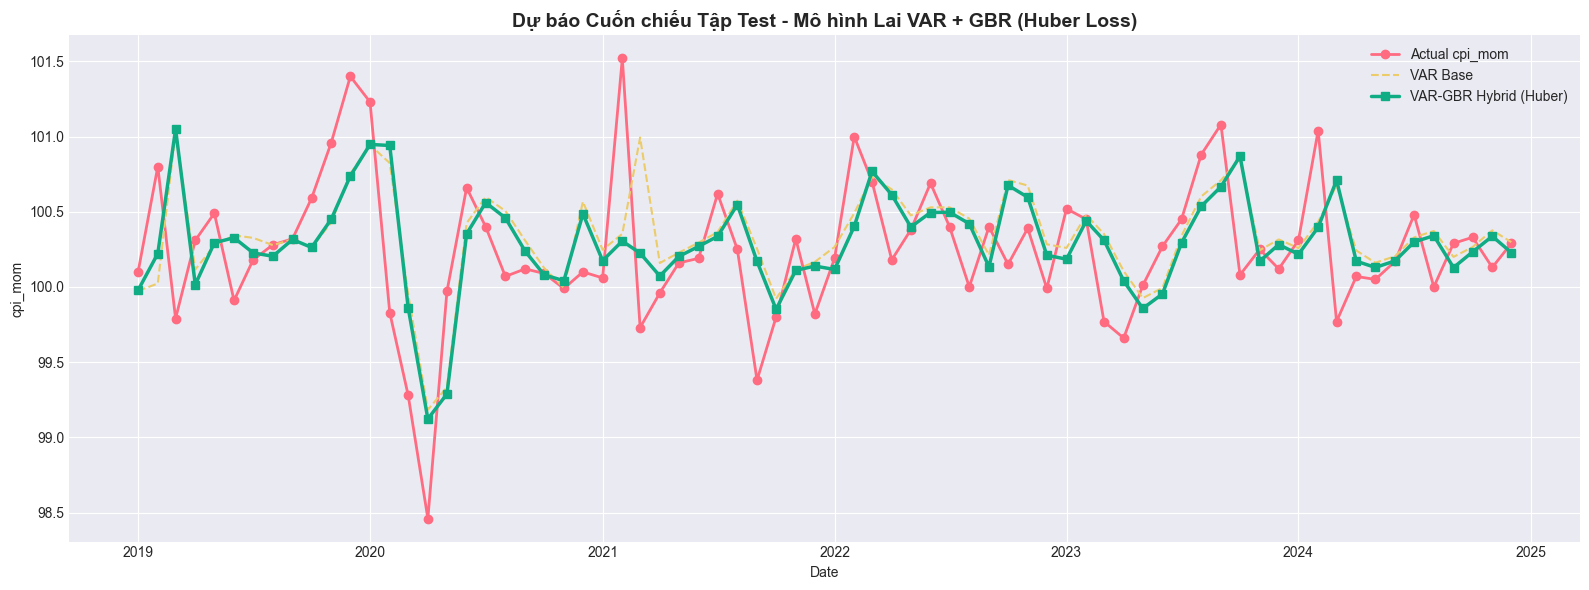

In [6]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tools.sm_exceptions import ValueWarning
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from math import sqrt

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=ValueWarning)
plt.style.use("seaborn-v0_8-darkgrid")

SCRIPT_DIR = os.getcwd()
DATA_DIR = os.path.join(SCRIPT_DIR, 'data', 'processed')

cleaned_data = pd.read_csv(os.path.join(DATA_DIR, 'cpi_02_06_selected_variables.csv'))
cleaned_data['date'] = pd.to_datetime(cleaned_data['date'])
df = cleaned_data.sort_values('date').reset_index(drop=True)

target_var = 'cpi_mom'
selected_vars = ['cpi_mom', 'broad_money', 'ppi_qoq', 'wti', 'policy_rate', 'gdp']
selected_vars = [v for v in selected_vars if v in df.columns]

df_var = df[['date']].copy()
for var in selected_vars:
    series = df[var].copy()
    if var == target_var:
        df_var[var] = series
    else:
        if (series > 0).all():
            df_var[f'dlog_{var}'] = np.log(series).diff()
        else:
            df_var[f'diff_{var}'] = series.diff()

df_var = df_var.dropna().reset_index(drop=True).set_index('date')
df_var.index.freq = 'MS'

# --- SỬA LỖI VĂNG VALUERAISE: Loại bỏ cột hằng số trong tập Train ---
initial_train_size = int(len(df_var) * 0.60)
cols_to_check = [c for c in df_var.columns if c != target_var]
constant_cols = [c for c in cols_to_check if df_var.iloc[:initial_train_size][c].std() == 0 or df_var.iloc[:initial_train_size][c].nunique() <= 1]

if constant_cols:
    print(f"Xóa bỏ các cột hằng số nhiễu trong cửa sổ train: {constant_cols}")
    df_var = df_var.drop(columns=constant_cols)

all_cols = df_var.columns.tolist()
exog_cols = [c for c in all_cols if c != target_var]
scaler = StandardScaler()
df_var[exog_cols] = scaler.fit_transform(df_var[exog_cols])

def create_hybrid_features(data, target, lag_res=2, lag_exog=1):
    df_feat = pd.DataFrame(index=data.index)
    df_feat['var_resid'] = data['var_resid']
    for l in range(1, lag_res + 1):
        df_feat[f'var_resid_lag{l}'] = data['var_resid'].shift(l)
    for col in data.columns:
        if col != 'var_resid' and col != target:
            for l in range(1, lag_exog + 1):
                df_feat[f'{col}_lag{l}'] = data[col].shift(l)
    return df_feat.dropna()

n_obs = len(df_var)
train_end = int(n_obs * 0.60)
valid_end = int(n_obs * 0.80)

train_df = df_var.iloc[:train_end]
valid_df = df_var.iloc[train_end:valid_end]
test_df = df_var.iloc[valid_end:]

print(f"Train size: {len(train_df)} | Valid size: {len(valid_df)} | Test size: {len(test_df)}")

best_lag = 2
var_base = VAR(train_df, freq='MS').fit(best_lag)
fitted_res = train_df.loc[train_df.index[best_lag:], target_var] - var_base.fittedvalues[target_var]

train_data_nn = train_df.loc[train_df.index[best_lag:]].copy()
train_data_nn['var_resid'] = fitted_res
nn_feats = create_hybrid_features(train_data_nn, target_var, lag_res=2, lag_exog=1)

X_tr = nn_feats.drop(columns=['var_resid'])
y_tr = nn_feats['var_resid']

param_grid = [0.01, 0.05, 0.1]
best_lr = 0.05
best_val_r2 = -np.inf

for lr in param_grid:
    tune_model = GradientBoostingRegressor(loss='huber', learning_rate=lr, n_estimators=100, max_depth=3, random_state=42)
    tune_model.fit(X_tr, y_tr)
    
    valid_preds = []
    for idx in range(len(valid_df)):
        curr_train = pd.concat([train_df, valid_df.iloc[:idx]])
        v_model = VAR(curr_train, freq='MS').fit(best_lag)
        v_pred = v_model.forecast(curr_train.values[-best_lag:], steps=1)[0][curr_train.columns.get_loc(target_var)]
        valid_preds.append(v_pred)
        
    val_r2 = r2_score(valid_df[target_var], valid_preds)
    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        best_lr = lr

print(f"Best Learning Rate từ Validation: {best_lr}")

rolling_dates = []
actual_values = []
var_predictions = []
hybrid_predictions = []

base_data_len = valid_end

for t in range(base_data_len, n_obs):
    current_train = df_var.iloc[:t].copy()
    actual_val = df_var.iloc[t][target_var]
    current_date = df_var.index[t]
    
    try:
        var_model = VAR(current_train, freq='MS')
        var_fitted = var_model.fit(best_lag)
        var_pred_val = var_fitted.forecast(current_train.values[-best_lag:], steps=1)[0][current_train.columns.get_loc(target_var)]
        
        resid_series = current_train.loc[current_train.index[best_lag:], target_var] - var_fitted.fittedvalues[target_var]
        train_nn = current_train.loc[current_train.index[best_lag:]].copy()
        train_nn['var_resid'] = resid_series
        
        gbr_feats = create_hybrid_features(train_nn, target_var, lag_res=2, lag_exog=1)
        X_train_gbr = gbr_feats.drop(columns=['var_resid'])
        y_train_gbr = gbr_feats['var_resid']
        
        gbr_model = GradientBoostingRegressor(
            loss='huber', 
            learning_rate=best_lr, 
            n_estimators=100, 
            max_depth=2, 
            alpha=0.9, 
            random_state=42
        )
        gbr_model.fit(X_train_gbr, y_train_gbr)
        
        extended = train_nn.copy()
        extended.loc[current_date] = current_train.iloc[-1]
        extended.loc[current_date, 'var_resid'] = current_train.iloc[-1][target_var] - var_pred_val
        
        full_feats = create_hybrid_features(extended, target_var, lag_res=2, lag_exog=1)
        X_test_step = full_feats.drop(columns=['var_resid']).iloc[[-1]]
        
        gbr_pred_resid = gbr_model.predict(X_test_step)[0]
        hybrid_pred_val = var_pred_val + gbr_pred_resid
        
        rolling_dates.append(current_date)
        actual_values.append(actual_val)
        var_predictions.append(var_pred_val)
        hybrid_predictions.append(hybrid_pred_val)
        
    except Exception as e:
        continue

results_df = pd.DataFrame({
    'Actual': actual_values,
    'VAR_Only': var_predictions,
    'VAR_GBR_Hybrid': hybrid_predictions
}, index=rolling_dates)

r2_var = r2_score(results_df['Actual'], results_df['VAR_Only'])
r2_hybrid = r2_score(results_df['Actual'], results_df['VAR_GBR_Hybrid'])
rmse_hybrid = sqrt(mean_squared_error(results_df['Actual'], results_df['VAR_GBR_Hybrid']))
mae_hybrid = mean_absolute_error(results_df['Actual'], results_df['VAR_GBR_Hybrid'])

print("\n" + "="*60)
print(" KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP")
print("="*60)
print(f"MÔ HÌNH VAR GỐC  ->  R2 Score: {r2_var:.4f}")
print(f"MÔ HÌNH VAR-GBR  ->  RMSE: {rmse_hybrid:.4f} | MAE: {mae_hybrid:.4f} | R2 Score: {r2_hybrid:.4f}")
print("="*60)

plt.figure(figsize=(16, 6))
plt.plot(results_df.index, results_df['Actual'], marker='o', color='#ff6b81', lw=2, label='Actual cpi_mom')
plt.plot(results_df.index, results_df['VAR_Only'], color='#eccc68', lw=1.5, ls='--', label='VAR Base')
plt.plot(results_df.index, results_df['VAR_GBR_Hybrid'], marker='s', color='#10ac84', lw=2.5, label='VAR-GBR Hybrid (Huber)')
plt.title('Dự báo Cuốn chiếu Tập Test - Mô hình Lai VAR + GBR (Huber Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('cpi_mom')
plt.legend()
plt.tight_layout()
plt.show()